In [1]:
#basic imports
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

#modeling
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression , Ridge, Lasso 
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings




In [4]:
df = pd.read_csv('data/stud.csv')

In [5]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
X =df.drop(columns='math_score',axis=1)
y=df['math_score']


In [7]:
# Create column transformer with 3 types of transformers
num_features=X.select_dtypes(exclude='object').columns
cat_features=X.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer


num_transformer =StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder',oh_transformer,cat_features),
        ('StandardScaler', num_transformer,num_features)
    ]
)

In [8]:
X=preprocessor.fit_transform(X)

In [11]:
# seperate train and test data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape


((800, 19), (200, 19))

In [13]:
#Create an evaluation matrix to give all metrics after model training
def evaluate_model(true,pred):
    mae = mean_absolute_error(true,pred)
    mse = mean_squared_error(true,pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(true,pred)
    return mae, rmse, r2


In [15]:
models={
    'linear regression': LinearRegression(),
    'lasso':Lasso(),
    'ridge':Ridge(),
    'k-neighbour regressor':KNeighborsRegressor(),
    'Decision tree': DecisionTreeRegressor(),
    'Random forest regressor':RandomForestRegressor(),
    'xgboost regressor':XGBRegressor(),
    'catboost regressor':CatBoostRegressor(verbose=False),
    'adaboost regressor':AdaBoostRegressor()   
}
model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)
    
    # make predictions
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)
    
    # evaluate model
    model_train_mae,model_train_rmse,model_train_r2=evaluate_model(y_train,y_train_pred)
    
    model_test_mae,model_test_rmse,model_test_r2=evaluate_model(y_test,y_test_pred)
    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print("model performence on training data")
    print(f"mae: {model_train_mae}")
    print(f"rmse: {model_train_rmse}")
    print(f"r2: {model_train_r2}")
    
    
    print("------------------------------------")
    
    print("modelperformence on test data ")
    print(f"mae: {model_test_mae}")
    print(f"rmse: {model_test_rmse}")
    print(f"r2: {model_test_r2}")
  
    r2_list.append(model_test_r2)
    
    print("="*35)
    print('\n')  

linear regression
model performence on training data
mae: 4.27880859375
rmse: 5.327359474652332
r2: 0.8741136595329527
------------------------------------
modelperformence on test data 
mae: 4.2259375
rmse: 5.40960336750764
r2: 0.8797402769404664


lasso
model performence on training data
mae: 5.206302661246526
rmse: 6.593815587795566
r2: 0.8071462015863456
------------------------------------
modelperformence on test data 
mae: 5.157881810347763
rmse: 6.51969453566742
r2: 0.8253197323627852


ridge
model performence on training data
mae: 4.264987823725981
rmse: 5.323324922741654
r2: 0.8743042615212909
------------------------------------
modelperformence on test data 
mae: 4.21110068801426
rmse: 5.390387016935638
r2: 0.8805931485028738


k-neighbour regressor
model performence on training data
mae: 4.51875
rmse: 5.712219358533074
r2: 0.8552680689060966
------------------------------------
modelperformence on test data 
mae: 5.615999999999999
rmse: 7.2516205085484176
r2: 0.78389765035

In [18]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name','R2_Score']).sort_values(by=['R2_Score'],ascending=False)

,Model Name,R2_Score
2,ridge,0.880593
0,linear regression,0.879740
7,catboost regressor,0.851632
5,Random forest regressor,0.849292
8,adaboost regressor,0.846568
6,xgboost regressor,0.827797
1,lasso,0.825320
3,k-neighbour regressor,0.783898
4,Decision tree,0.728362


In [19]:
lin_model=LinearRegression(fit_intercept=True)
lin_model.fit(X_train,y_train)
y_pred=lin_model.predict(X_test)
score=r2_score(y_test,y_pred)*100
print("accuracy of model is %.2f" %score)

accuracy of model is 87.97


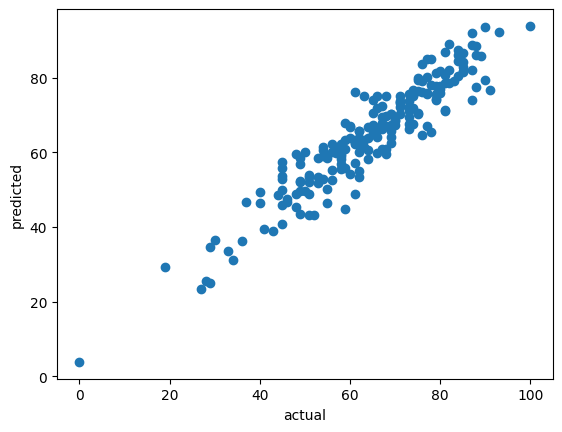

In [20]:
plt.scatter(y_test,y_pred)
plt.xlabel("actual")
plt.ylabel('predicted')
plt.show()

<Axes: xlabel='math_score'>

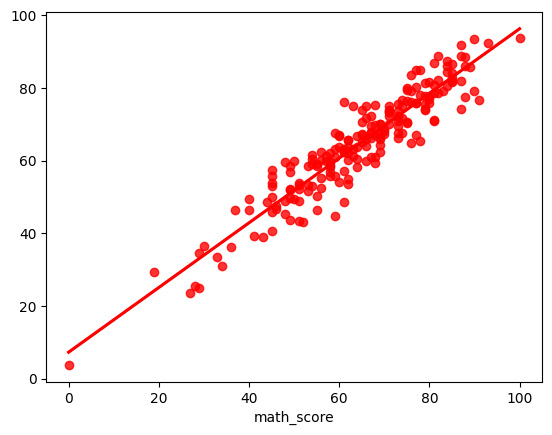

In [22]:
sns.regplot(x=y_test, y=y_pred,ci=None,color='red')

In [24]:
pred_df=pd.DataFrame({'Actual Values':y_test,'Predicted Values': y_pred, 'Diffrence':y_test-y_pred})
pred_df

,Actual Values,Predicted Values,Diffrence
521,91,76.703125,14.296875
737,53,58.578125,-5.578125
740,80,76.828125,3.171875
660,74,76.734375,-2.734375
411,84,87.484375,-3.484375
...,...,...,...
408,52,43.125000,8.875000
332,62,62.109375,-0.109375
208,74,67.562500,6.437500
613,65,67.328125,-2.328125
